In [5]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# load the dataser so we can start cleaning and analyzing it

FP=pd.read_csv("/content/drive/MyDrive/ames_data/AmesHousing.csv")


In [8]:
FP=pd.read_csv("/content/drive/MyDrive/ames_data/AmesHousing.csv")
def clean_data():
    print(FP.head())#show the first rows to see the data
    print("shape:",FP.shape)#see how many rows and columns are in the data
    FP.info()# check what type of data each column has
    print(FP.isnull().sum())#cheack where data is missing
    return FP
def fix_types(FP):
# fix the type of some columns
  FP["MS SubClass"]=FP["MS SubClass"].astype("category")
  FP["Mo Sold"]=FP["Mo Sold"].astype("category")
  return FP
  # function to check mssing vlaues
def find_missing(FP):
    #show how many missing vlaues exist in each columns
    missing =FP.isnull().sum().sort_values(ascending=False)
    print(missing)
    return FP


In [9]:
def fill_missing(FP):
    # get columns that contain numbers
    nums_col=FP.select_dtypes(include=["number"]).columns
    # get columns that contain text or categories
    catg_col=FP.select_dtypes(include=["object","category"]).columns
    # fill mssing numbers with the median value
    FP[nums_col]=FP[nums_col].fillna(FP[nums_col].median())
    # fill missing categorical values with the most common value
    FP[catg_col]=FP[catg_col].fillna(FP[catg_col].mode().iloc[0])
    return FP

In [10]:
#check if there are repeated rows
def remove_duplicates(FP):
    print("duplicates:",FP.duplicated().sum())
    #remove duplicates rows
    FP=FP.drop_duplicates()
    return FP

In [11]:
def cap_outliers(FP):
    #draw a boxplot to see unusual values
    FP.boxplot(column="SalePrice")
    plt.show()
    #limit very large vlaues
    p99=FP["SalePrice"].quantile(0.99)
    FP["SalePrice"]=FP["SalePrice"].clip(upper=p99)
    return FP

In [12]:
def final_checks(FP):
  #final checks to ensure the data is clean
  assert FP["SalePrice"].isnull().sum()==0
  assert(FP["SalePrice"]>0).all()
  assert FP.shape[0]>0
  return FP


   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0       

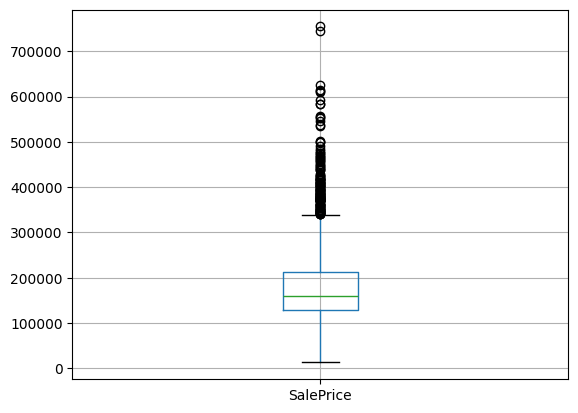

In [13]:
#main function that loads and cleans it step by step
def clean_data():
  FP=pd.read_csv("/content/drive/MyDrive/ames_data/AmesHousing.csv")
  print(FP.head())
  print("shape:",FP.shape)
  FP.info()
  FP=fix_types(FP)# run each cleaning step in order
  FP=find_missing(FP)#check missing vlaues
  FP=fill_missing(FP)#fill missing data
  FP=remove_duplicates(FP)#remove duplicates rows
  FP=cap_outliers(FP)#detect and limit extreme vlaues
  FP=final_checks(FP)#perform final checks
  return FP
FP_clean=clean_data()

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0       

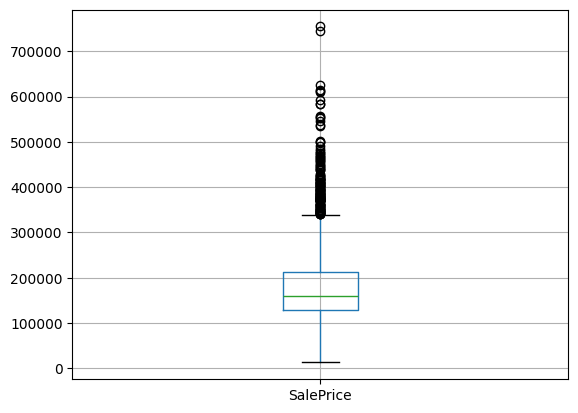

In [14]:
FP_clean=clean_data()
FP_clean.to_csv("/content/drive/MyDrive/ames_data/AmesHousing_clean.csv",index=False)